In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data/FAF5_join_meta.csv')

C:\Users\user\AppData\Local\Temp\ipykernel_3164\3290435484.py:1: DtypeWarning: Columns (39,40,50,51) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/FAF5_join_meta.csv')


In [3]:
for col in df.select_dtypes('object').columns:
    df[col] = df[col].astype('category')

In [4]:
# 칼럼 전체가 결측치인 칼럼 제거

# 국내/수입/수출로 분리
dms_df = df.loc[df['trade_type'] == 1]
fr_import = df.loc[df['fr_orig'].notna(),]
fr_export = df.loc[df['fr_dest'].notna(),]

# 필요없는 칼럼(칼럼 전체가 NA인 값) 제거
dms_df = dms_df.dropna(axis = 1, how = 'all')
fr_import = fr_import.dropna(axis = 1, how = 'all')
fr_export = fr_export.dropna(axis = 1, how = 'all')

In [5]:
# 국내 운송 51만건, 해외 수입 100만건, 해외 수출 95만건
print('미국 국내 운송 건수:', dms_df.shape)
print('미국 해외 수입 건수:', fr_import.shape)
print('미국 해외 수출 건수:', fr_export.shape)

print(len(dms_df) + len(fr_import) + len(fr_export))
print(len(df))

미국 국내 운송 건수: (518713, 44)
미국 해외 수입 건수: (1006178, 48)
미국 해외 수출 건수: (950389, 48)
2475280
2475280


C:\Users\user\AppData\Local\Temp\ipykernel_3164\2749357383.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  orig_tons_top10_yearly = melted_all.groupby('year').apply(lambda x: x.nlargest(10, 'tons')).reset_index(drop = True)


['Texas', 'California', 'Illinois', 'Louisiana', 'Ohio', 'Florida', 'Pennsylvania', 'Indiana', 'Minnesota', 'Iowa']
Categories (10, object): ['California', 'Florida', 'Illinois', 'Indiana', ..., 'Minnesota', 'Ohio', 'Pennsylvania', 'Texas']


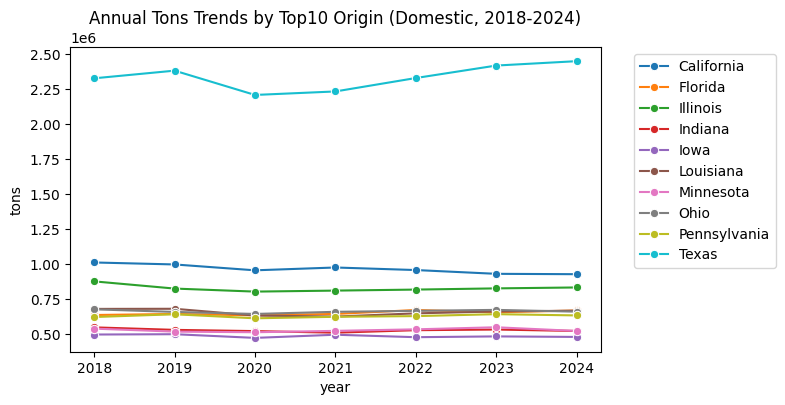

In [15]:
dms_orig_tons = dms_df.groupby(['state_orig_nm'], observed = True)\
[[f'tons_{year}' for year in range(2018,2025)]].sum().reset_index()

melted_all = dms_orig_tons.melt(id_vars = 'state_orig_nm',
                                var_name = 'year',
                                value_name = 'tons').reset_index(drop = True)

melted_all['year'] = melted_all['year'].str.replace('tons_', '').astype(int)

orig_tons_top10_yearly = melted_all.groupby('year').apply(lambda x: x.nlargest(10, 'tons')).reset_index(drop = True)

if orig_tons_top10_yearly['state_orig_nm'].dtype.name == 'category':
    orig_tons_top10_yearly['state_orig_nm'] = orig_tons_top10_yearly['state_orig_nm'].cat.remove_unused_categories()

print(orig_tons_top10_yearly['state_orig_nm'].unique())

plt.figure(figsize = (8,4))
sns.lineplot(data=orig_tons_top10_yearly, x='year', y='tons', hue='state_orig_nm', marker='o')
plt.title('Annual Tons Trends by Top10 Origin (Domestic, 2018-2024)')
plt.legend(bbox_to_anchor = (1.05,1), loc = 'upper left')
plt.tight_layout()
plt.show()

['Texas', 'California', 'Illinois', 'Pennsylvania', 'Ohio', 'New York', 'Michigan', 'Florida', 'Georgia', 'New Jersey']
Categories (10, object): ['California', 'Florida', 'Georgia', 'Illinois', ..., 'New York', 'Ohio', 'Pennsylvania', 'Texas']


C:\Users\user\AppData\Local\Temp\ipykernel_3164\1812730448.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  orig_tons_top10_yearly = melted_all.groupby('year').apply(lambda x: x.nlargest(10, 'value')).reset_index(drop = True)


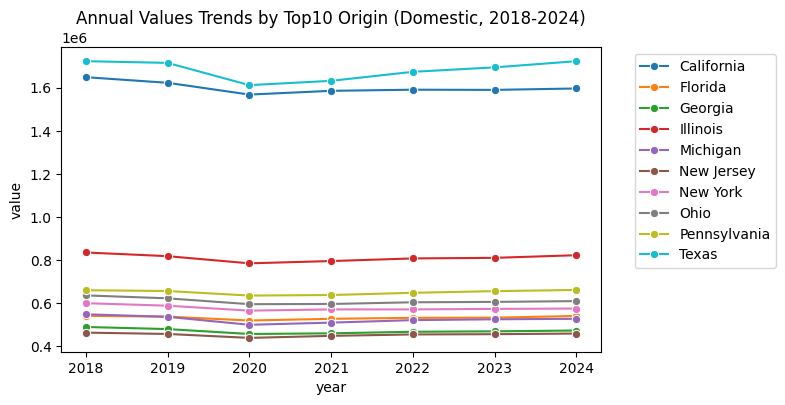

In [16]:
dms_orig_tons = dms_df.groupby(['state_orig_nm'], observed = True)\
[[f'value_{year}' for year in range(2018,2025)]].sum().reset_index()

melted_all = dms_orig_tons.melt(id_vars = 'state_orig_nm',
                                var_name = 'year',
                                value_name = 'value').reset_index(drop = True)

melted_all['year'] = melted_all['year'].str.replace('value_', '').astype(int)

orig_tons_top10_yearly = melted_all.groupby('year').apply(lambda x: x.nlargest(10, 'value')).reset_index(drop = True)

if orig_tons_top10_yearly['state_orig_nm'].dtype.name == 'category':
    orig_tons_top10_yearly['state_orig_nm'] = orig_tons_top10_yearly['state_orig_nm'].cat.remove_unused_categories()

print(orig_tons_top10_yearly['state_orig_nm'].unique())

plt.figure(figsize = (8,4))
sns.lineplot(data=orig_tons_top10_yearly, x='year', y='value', hue='state_orig_nm', marker='o')
plt.title('Annual Values Trends by Top10 Origin (Domestic, 2018-2024)')
plt.legend(bbox_to_anchor = (1.05,1), loc = 'upper left')
plt.tight_layout()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_3164\3550986730.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  orig_tons_top10_yearly = melted_all.groupby('year').apply(lambda x: x.nlargest(10, 'tons')).reset_index(drop = True)


['Texas', 'California', 'Illinois', 'Louisiana', 'Florida', ..., 'Indiana', 'Pennsylvania', 'Minnesota', 'Michigan', 'New York']
Length: 11
Categories (11, object): ['California', 'Florida', 'Illinois', 'Indiana', ..., 'New York', 'Ohio', 'Pennsylvania', 'Texas']


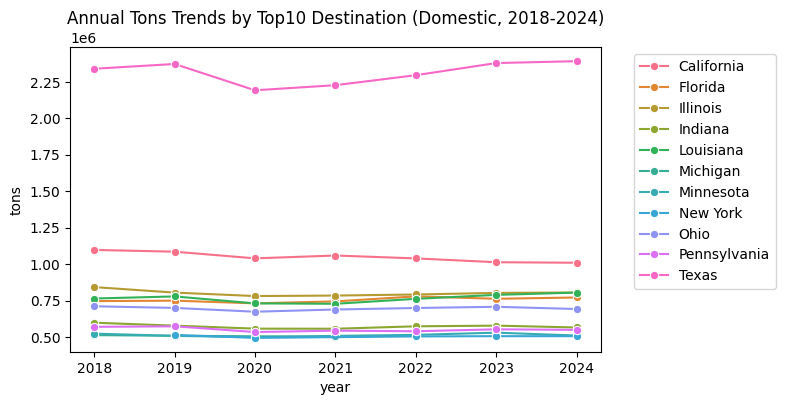

In [ ]:
dms_orig_tons = dms_df.groupby(['state_dest_nm'], observed = True)\
[[f'tons_{year}' for year in range(2018,2025)]].sum().reset_index()

melted_all = dms_orig_tons.melt(id_vars = 'state_dest_nm',
                                var_name = 'year',
                                value_name = 'tons').reset_index(drop = True)

melted_all['year'] = melted_all['year'].str.replace('tons_', '').astype(int)

orig_tons_top10_yearly = melted_all.groupby('year').apply(lambda x: x.nlargest(10, 'tons')).reset_index(drop = True)

if orig_tons_top10_yearly['state_dest_nm'].dtype.name == 'category':
    orig_tons_top10_yearly['state_dest_nm'] = orig_tons_top10_yearly['state_dest_nm'].cat.remove_unused_categories()

print(orig_tons_top10_yearly['state_dest_nm'].unique())

plt.figure(figsize = (8,4))
sns.lineplot(data=orig_tons_top10_yearly, x='year', y='tons', hue='state_dest_nm', marker='o')
plt.title('Annual Tons Trends by Top10 Destination (Domestic, 2018-2024)')
plt.legend(bbox_to_anchor = (1.05,1), loc = 'upper left')
plt.tight_layout()
plt.show()

['Texas', 'California', 'Illinois', 'Florida', 'Ohio', 'New York', 'Pennsylvania', 'Michigan', 'Georgia', 'Indiana']
Categories (10, object): ['California', 'Florida', 'Georgia', 'Illinois', ..., 'New York', 'Ohio', 'Pennsylvania', 'Texas']


C:\Users\user\AppData\Local\Temp\ipykernel_3164\1279695332.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  orig_tons_top10_yearly = melted_all.groupby('year').apply(lambda x: x.nlargest(10, 'value')).reset_index(drop = True)


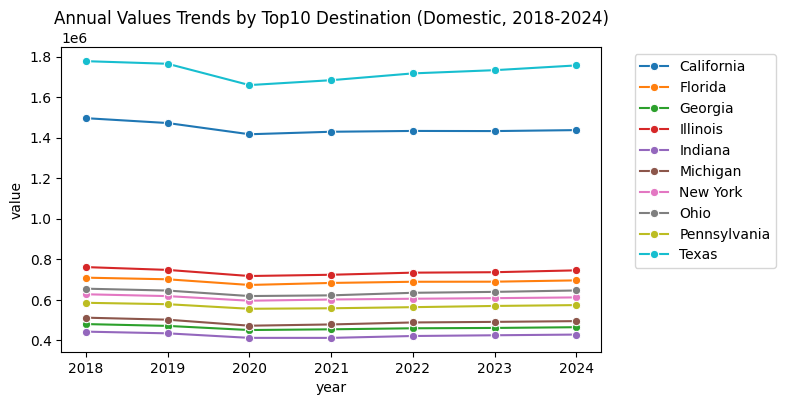

In [ ]:
dms_orig_tons = dms_df.groupby(['state_dest_nm'], observed = True)\
[[f'value_{year}' for year in range(2018,2025)]].sum().reset_index()

melted_all = dms_orig_tons.melt(id_vars = 'state_dest_nm',
                                var_name = 'year',
                                value_name = 'value').reset_index(drop = True)

melted_all['year'] = melted_all['year'].str.replace('value_', '').astype(int)

orig_tons_top10_yearly = melted_all.groupby('year').apply(lambda x: x.nlargest(10, 'value')).reset_index(drop = True)

if orig_tons_top10_yearly['state_dest_nm'].dtype.name == 'category':
    orig_tons_top10_yearly['state_dest_nm'] = orig_tons_top10_yearly['state_dest_nm'].cat.remove_unused_categories()

print(orig_tons_top10_yearly['state_dest_nm'].unique())

plt.figure(figsize = (8,4))
sns.lineplot(data=orig_tons_top10_yearly, x='year', y='value', hue='state_dest_nm', marker='o')
plt.title('Annual Values Trends by Top10 Destination (Domestic, 2018-2024)')
plt.legend(bbox_to_anchor = (1.05,1), loc = 'upper left')
plt.tight_layout()
plt.show()

톤 기준 출발지 - Texas ... Califonia, Illinois / 도착지 - Texas ... Califonia, Illinois, Louisiana

돈 기준 출발지 - Texas, Califonia, ..., Illinois / 도착지 - Texas, Califonia, Illinois, Florida

---

출발지 톤 기준 Top10 list - ['Texas', 'California', 'Illinois', 'Louisiana', 'Ohio', 'Florida', 'Pennsylvania', 'Indiana', 'Minnesota', 'Iowa']

도착지 톤 기준 Top10 list - ['Texas', 'California', 'Illinois', 'Louisiana', 'Florida', 'Ohio', 'Indiana', 'Pennsylvania', 'Minnesota', 'Michigan', 'New York']

---

출발지 돈 기준 Top10 list - ['Texas', 'California', 'Illinois', 'Pennsylvania', 'Ohio', 'New York', 'Michigan', 'Florida', 'Georgia', 'New Jersey']

도착지 돈 기준 Top10 list - ['Texas', 'California', 'Illinois', 'Florida', 'Ohio', 'New York', 'Pennsylvania', 'Michigan', 'Georgia', 'Indiana']

---

주요 허브 주 - ['Texas', 'California', 'Illinois', 'Ohio', 'Florida', 'Pensylvania']

주요 물류량 - ['Louisiana', 'Indiana', 'Minnesota', 'Iowa?' ]

주요 가치량 - ['New York', 'Michigan', 'Georgia', 'New Jersey?(출발)']

['Texas', 'California', 'North Dakota', 'Louisiana', 'New Jersey', 'Michigan', 'New York', 'Washington', 'Montana', 'Florida']
Categories (10, object): ['California', 'Florida', 'Louisiana', 'Michigan', ..., 'New York', 'North Dakota', 'Texas', 'Washington']


C:\Users\user\AppData\Local\Temp\ipykernel_3164\513193194.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  orig_tons_top10_yearly = melted_all.groupby('year').apply(lambda x: x.nlargest(10, 'tons')).reset_index(drop = True)


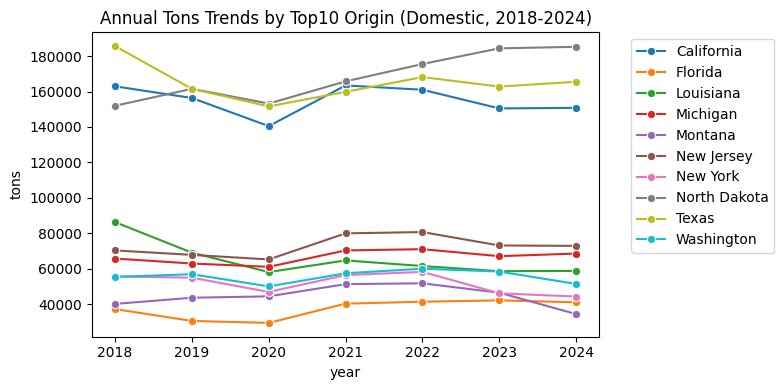

In [21]:
dms_orig_tons = fr_import.groupby(['state_orig_nm'], observed = True)\
[[f'tons_{year}' for year in range(2018,2025)]].sum().reset_index()

melted_all = dms_orig_tons.melt(id_vars = 'state_orig_nm',
                                var_name = 'year',
                                value_name = 'tons').reset_index(drop = True)

melted_all['year'] = melted_all['year'].str.replace('tons_', '').astype(int)

orig_tons_top10_yearly = melted_all.groupby('year').apply(lambda x: x.nlargest(10, 'tons')).reset_index(drop = True)

if orig_tons_top10_yearly['state_orig_nm'].dtype.name == 'category':
    orig_tons_top10_yearly['state_orig_nm'] = orig_tons_top10_yearly['state_orig_nm'].cat.remove_unused_categories()

print(orig_tons_top10_yearly['state_orig_nm'].unique())

plt.figure(figsize = (8,4))
sns.lineplot(data=orig_tons_top10_yearly, x='year', y='tons', hue='state_orig_nm', marker='o')
plt.title('Annual Tons Trends by Top10 Origin (Domestic, 2018-2024)')
plt.legend(bbox_to_anchor = (1.05,1), loc = 'upper left')
plt.tight_layout()
plt.show()

['California', 'Texas', 'New Jersey', 'New York', 'Illinois', ..., 'Florida', 'Washington', 'Kentucky', 'South Carolina', 'North Dakota']
Length: 12
Categories (12, object): ['California', 'Florida', 'Georgia', 'Illinois', ..., 'North Dakota', 'South Carolina', 'Texas', 'Washington']


C:\Users\user\AppData\Local\Temp\ipykernel_3164\3838245510.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  orig_tons_top10_yearly = melted_all.groupby('year').apply(lambda x: x.nlargest(10, 'value')).reset_index(drop = True)


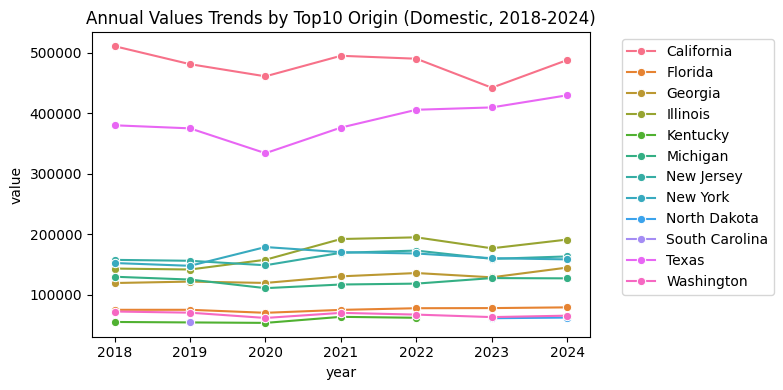

In [22]:
dms_orig_tons = fr_import.groupby(['state_orig_nm'], observed = True)\
[[f'value_{year}' for year in range(2018,2025)]].sum().reset_index()

melted_all = dms_orig_tons.melt(id_vars = 'state_orig_nm',
                                var_name = 'year',
                                value_name = 'value').reset_index(drop = True)

melted_all['year'] = melted_all['year'].str.replace('value_', '').astype(int)

orig_tons_top10_yearly = melted_all.groupby('year').apply(lambda x: x.nlargest(10, 'value')).reset_index(drop = True)

if orig_tons_top10_yearly['state_orig_nm'].dtype.name == 'category':
    orig_tons_top10_yearly['state_orig_nm'] = orig_tons_top10_yearly['state_orig_nm'].cat.remove_unused_categories()

print(orig_tons_top10_yearly['state_orig_nm'].unique())

plt.figure(figsize = (8,4))
sns.lineplot(data=orig_tons_top10_yearly, x='year', y='value', hue='state_orig_nm', marker='o')
plt.title('Annual Values Trends by Top10 Origin (Domestic, 2018-2024)')
plt.legend(bbox_to_anchor = (1.05,1), loc = 'upper left')
plt.tight_layout()
plt.show()

['Texas', 'California', 'Illinois', 'Louisiana', 'New Jersey', ..., 'Michigan', 'Florida', 'New York', 'Pennsylvania', 'Minnesota']
Length: 11
Categories (11, object): ['California', 'Florida', 'Illinois', 'Louisiana', ..., 'New York', 'Pennsylvania', 'Texas', 'Washington']


C:\Users\user\AppData\Local\Temp\ipykernel_3164\1369314860.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  orig_tons_top10_yearly = melted_all.groupby('year').apply(lambda x: x.nlargest(10, 'tons')).reset_index(drop = True)


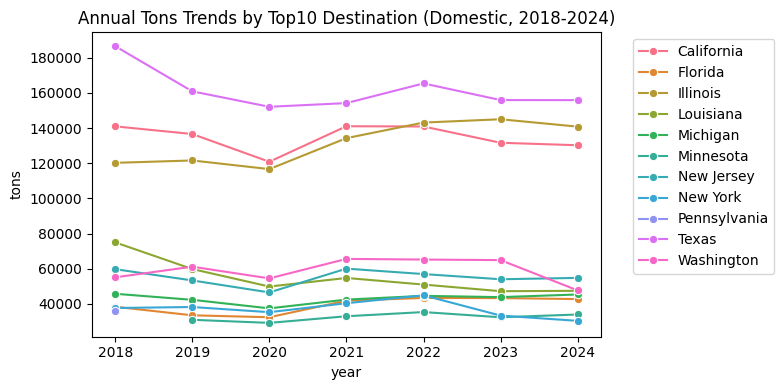

In [ ]:
dms_orig_tons = fr_import.groupby(['state_dest_nm'], observed = True)\
[[f'tons_{year}' for year in range(2018,2025)]].sum().reset_index()

melted_all = dms_orig_tons.melt(id_vars = 'state_dest_nm',
                                var_name = 'year',
                                value_name = 'tons').reset_index(drop = True)

melted_all['year'] = melted_all['year'].str.replace('tons_', '').astype(int)

orig_tons_top10_yearly = melted_all.groupby('year').apply(lambda x: x.nlargest(10, 'tons')).reset_index(drop = True)

if orig_tons_top10_yearly['state_dest_nm'].dtype.name == 'category':
    orig_tons_top10_yearly['state_dest_nm'] = orig_tons_top10_yearly['state_dest_nm'].cat.remove_unused_categories()

print(orig_tons_top10_yearly['state_dest_nm'].unique())

plt.figure(figsize = (8,4))
sns.lineplot(data=orig_tons_top10_yearly, x='year', y='tons', hue='state_dest_nm', marker='o')
plt.title('Annual Tons Trends by Top10 Destination (Domestic, 2018-2024)')
plt.legend(bbox_to_anchor = (1.05,1), loc = 'upper left')
plt.tight_layout()
plt.show()

['California', 'Texas', 'Illinois', 'Michigan', 'New York', 'New Jersey', 'Georgia', 'Tennessee', 'Pennsylvania', 'Florida']
Categories (10, object): ['California', 'Florida', 'Georgia', 'Illinois', ..., 'New York', 'Pennsylvania', 'Tennessee', 'Texas']


C:\Users\user\AppData\Local\Temp\ipykernel_3164\1368979388.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  orig_tons_top10_yearly = melted_all.groupby('year').apply(lambda x: x.nlargest(10, 'value')).reset_index(drop = True)


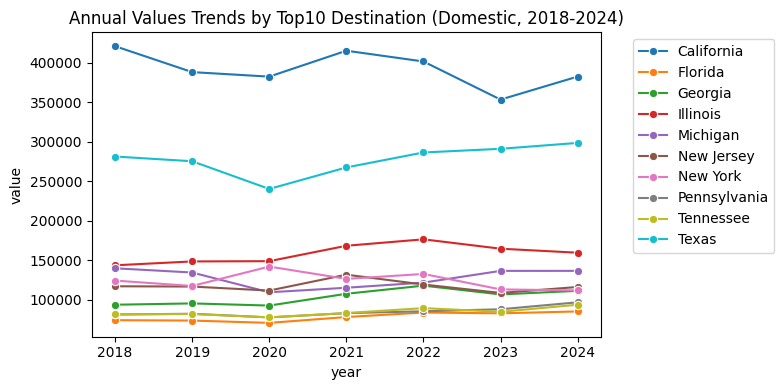

In [26]:
dms_orig_tons = fr_import.groupby(['state_dest_nm'], observed = True)\
[[f'value_{year}' for year in range(2018,2025)]].sum().reset_index()

melted_all = dms_orig_tons.melt(id_vars = 'state_dest_nm',
                                var_name = 'year',
                                value_name = 'value').reset_index(drop = True)

melted_all['year'] = melted_all['year'].str.replace('value_', '').astype(int)

orig_tons_top10_yearly = melted_all.groupby('year').apply(lambda x: x.nlargest(10, 'value')).reset_index(drop = True)

if orig_tons_top10_yearly['state_dest_nm'].dtype.name == 'category':
    orig_tons_top10_yearly['state_dest_nm'] = orig_tons_top10_yearly['state_dest_nm'].cat.remove_unused_categories()

print(orig_tons_top10_yearly['state_dest_nm'].unique())

plt.figure(figsize = (8,4))
sns.lineplot(data=orig_tons_top10_yearly, x='year', y='value', hue='state_dest_nm', marker='o')
plt.title('Annual Values Trends by Top10 Destination (Domestic, 2018-2024)')
plt.legend(bbox_to_anchor = (1.05,1), loc = 'upper left')
plt.tight_layout()
plt.show()

출발지 톤 기준-  'Texas', 'North Dakota', 'California'

출발지 돈 기준 - 'Texas', 'California'

도착지 톤 기준 - 'Texas', 'California', 'Illinois'

도착지 돈 기준 - 'Texas', 'California', 'New York'

---

['Texas', 'California', 'North Dakota', 'Louisiana', 'New Jersey', 'Michigan', 'New York', 'Washington', 'Montana', 'Florida']

['California', 'Texas', 'New Jersey', 'New York', 'Illinois', 'Georgia', 'Michigan', 'Florida', 'Washington', 'Kentucky', 'South Carolina', 'North Dakota']

['Texas', 'California', 'Illinois', 'Louisiana', 'New Jersey', ''Washington', 'Michigan', 'Florida', 'New York', 'Pennsylvania', 'Minnesota']

['California', 'Texas', 'Illinois', 'Michigan', 'New York', 'New Jersey', 'Georgia', 'Tennessee', 'Pennsylvania', 'Florida']

---

수입 주요 허브 - Texas, California, Louisiana, New Jersey, Michigan, New York, Washington, Florida, Illinois

주요 출발지 - North Dakota

주요 도착지 - Georgia

C:\Users\user\AppData\Local\Temp\ipykernel_3164\4130144118.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  orig_tons_top10_yearly = melted_all.groupby('year').apply(lambda x: x.nlargest(10, 'tons')).reset_index(drop = True)


['Texas', 'Louisiana', 'Washington', 'California', 'West Virginia', ..., 'Ohio', 'New York', 'Virginia', 'Minnesota', 'Alabama']
Length: 13
Categories (13, object): ['Alabama', 'California', 'Illinois', 'Louisiana', ..., 'Texas', 'Virginia', 'Washington', 'West Virginia']


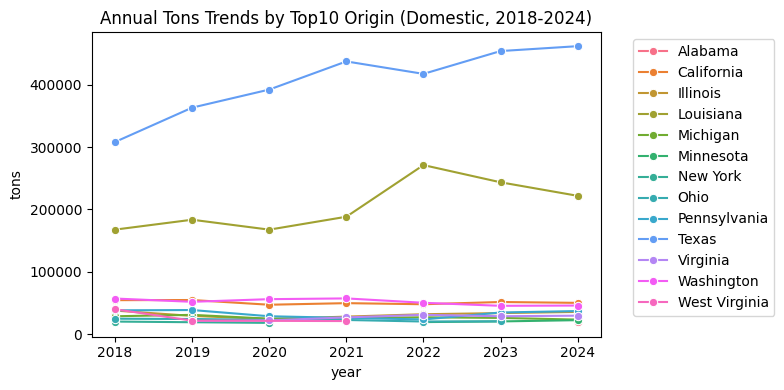

In [25]:
dms_orig_tons = fr_export.groupby(['state_orig_nm'], observed = True)\
[[f'tons_{year}' for year in range(2018,2025)]].sum().reset_index()

melted_all = dms_orig_tons.melt(id_vars = 'state_orig_nm',
                                var_name = 'year',
                                value_name = 'tons').reset_index(drop = True)

melted_all['year'] = melted_all['year'].str.replace('tons_', '').astype(int)

orig_tons_top10_yearly = melted_all.groupby('year').apply(lambda x: x.nlargest(10, 'tons')).reset_index(drop = True)

if orig_tons_top10_yearly['state_orig_nm'].dtype.name == 'category':
    orig_tons_top10_yearly['state_orig_nm'] = orig_tons_top10_yearly['state_orig_nm'].cat.remove_unused_categories()

print(orig_tons_top10_yearly['state_orig_nm'].unique())

plt.figure(figsize = (8,4))
sns.lineplot(data=orig_tons_top10_yearly, x='year', y='tons', hue='state_orig_nm', marker='o')
plt.title('Annual Tons Trends by Top10 Origin (Domestic, 2018-2024)')
plt.legend(bbox_to_anchor = (1.05,1), loc = 'upper left')
plt.tight_layout()
plt.show()

['Texas', 'California', 'New York', 'Washington', 'Michigan', ..., 'Florida', 'Ohio', 'Pennsylvania', 'New Jersey', 'Indiana']
Length: 12
Categories (12, object): ['California', 'Florida', 'Illinois', 'Indiana', ..., 'Ohio', 'Pennsylvania', 'Texas', 'Washington']


C:\Users\user\AppData\Local\Temp\ipykernel_3164\3108386009.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  orig_tons_top10_yearly = melted_all.groupby('year').apply(lambda x: x.nlargest(10, 'value')).reset_index(drop = True)


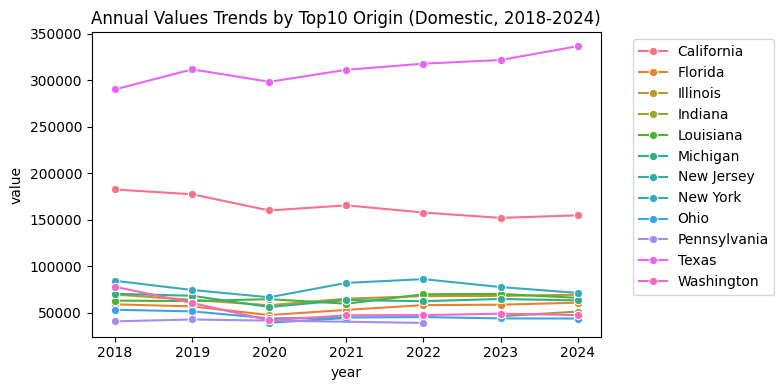

In [27]:
dms_orig_tons = fr_export.groupby(['state_orig_nm'], observed = True)\
[[f'value_{year}' for year in range(2018,2025)]].sum().reset_index()

melted_all = dms_orig_tons.melt(id_vars = 'state_orig_nm',
                                var_name = 'year',
                                value_name = 'value').reset_index(drop = True)

melted_all['year'] = melted_all['year'].str.replace('value_', '').astype(int)

orig_tons_top10_yearly = melted_all.groupby('year').apply(lambda x: x.nlargest(10, 'value')).reset_index(drop = True)

if orig_tons_top10_yearly['state_orig_nm'].dtype.name == 'category':
    orig_tons_top10_yearly['state_orig_nm'] = orig_tons_top10_yearly['state_orig_nm'].cat.remove_unused_categories()

print(orig_tons_top10_yearly['state_orig_nm'].unique())

plt.figure(figsize = (8,4))
sns.lineplot(data=orig_tons_top10_yearly, x='year', y='value', hue='state_orig_nm', marker='o')
plt.title('Annual Values Trends by Top10 Origin (Domestic, 2018-2024)')
plt.legend(bbox_to_anchor = (1.05,1), loc = 'upper left')
plt.tight_layout()
plt.show()

['Texas', 'Louisiana', 'California', 'Washington', 'Michigan', 'Virginia', 'New York', 'North Dakota', 'Maryland', 'Georgia']
Categories (10, object): ['California', 'Georgia', 'Louisiana', 'Maryland', ..., 'North Dakota', 'Texas', 'Virginia', 'Washington']


C:\Users\user\AppData\Local\Temp\ipykernel_3164\763494506.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  orig_tons_top10_yearly = melted_all.groupby('year').apply(lambda x: x.nlargest(10, 'tons')).reset_index(drop = True)


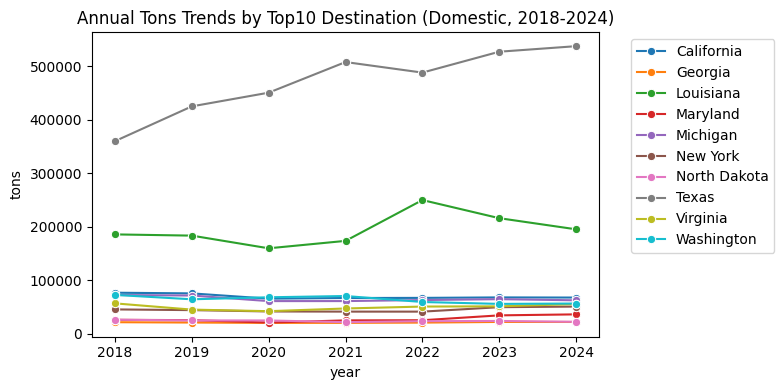

In [28]:
dms_orig_tons = fr_export.groupby(['state_dest_nm'], observed = True)\
[[f'tons_{year}' for year in range(2018,2025)]].sum().reset_index()

melted_all = dms_orig_tons.melt(id_vars = 'state_dest_nm',
                                var_name = 'year',
                                value_name = 'tons').reset_index(drop = True)

melted_all['year'] = melted_all['year'].str.replace('tons_', '').astype(int)

orig_tons_top10_yearly = melted_all.groupby('year').apply(lambda x: x.nlargest(10, 'tons')).reset_index(drop = True)

if orig_tons_top10_yearly['state_dest_nm'].dtype.name == 'category':
    orig_tons_top10_yearly['state_dest_nm'] = orig_tons_top10_yearly['state_dest_nm'].cat.remove_unused_categories()

print(orig_tons_top10_yearly['state_dest_nm'].unique())

plt.figure(figsize = (8,4))
sns.lineplot(data=orig_tons_top10_yearly, x='year', y='tons', hue='state_dest_nm', marker='o')
plt.title('Annual Tons Trends by Top10 Destination (Domestic, 2018-2024)')
plt.legend(bbox_to_anchor = (1.05,1), loc = 'upper left')
plt.tight_layout()
plt.show()

['Texas', 'California', 'New York', 'Michigan', 'Washington', 'Florida', 'Louisiana', 'Illinois', 'Georgia', 'Kentucky']
Categories (10, object): ['California', 'Florida', 'Georgia', 'Illinois', ..., 'Michigan', 'New York', 'Texas', 'Washington']


C:\Users\user\AppData\Local\Temp\ipykernel_3164\3072911696.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  orig_tons_top10_yearly = melted_all.groupby('year').apply(lambda x: x.nlargest(10, 'value')).reset_index(drop = True)


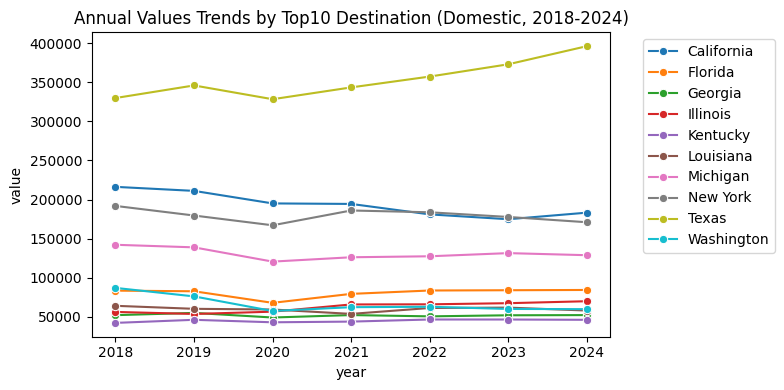

In [29]:
dms_orig_tons = fr_export.groupby(['state_dest_nm'], observed = True)\
[[f'value_{year}' for year in range(2018,2025)]].sum().reset_index()

melted_all = dms_orig_tons.melt(id_vars = 'state_dest_nm',
                                var_name = 'year',
                                value_name = 'value').reset_index(drop = True)

melted_all['year'] = melted_all['year'].str.replace('value_', '').astype(int)

orig_tons_top10_yearly = melted_all.groupby('year').apply(lambda x: x.nlargest(10, 'value')).reset_index(drop = True)

if orig_tons_top10_yearly['state_dest_nm'].dtype.name == 'category':
    orig_tons_top10_yearly['state_dest_nm'] = orig_tons_top10_yearly['state_dest_nm'].cat.remove_unused_categories()

print(orig_tons_top10_yearly['state_dest_nm'].unique())

plt.figure(figsize = (8,4))
sns.lineplot(data=orig_tons_top10_yearly, x='year', y='value', hue='state_dest_nm', marker='o')
plt.title('Annual Values Trends by Top10 Destination (Domestic, 2018-2024)')
plt.legend(bbox_to_anchor = (1.05,1), loc = 'upper left')
plt.tight_layout()
plt.show()

In [ ]:
west = ['California', 'Washington']

south = ['Texas', 'Georgia', 'Florida', 'Louisiana']

midwest = ['Illinois', 'Ohio', 'Indiana', 'Michigan', 'Minnesota', 'Iowa']

northeast = ['New York', 'New Jersey', 'Pennsylvania']